# Figure 2: Microdiversity Analaysis

- Concordance dot plots
- Concordance types per comparison
- Monophyletic proportion analysis 

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import random
import matplotlib.patches as mpatches
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from Bio import Phylo
import os

In [2]:
#some global color schemes
my_cst_cmap = matplotlib.colors.ListedColormap(['#fe0308', '#86c61f','#ff7200','#448a73','#221886','#fae50d'])
my_timepoint_cmap = matplotlib.colors.ListedColormap(['#4d4f4e','#c2c4c2'])
my_cv_cmap = matplotlib.colors.ListedColormap(['#5924ed','#9fafe0'])
my_concord_cmap =  matplotlib.colors.ListedColormap(['#f5b216','#1bbabf', '#474973'])

bodysite_colors = {
    'C':'#5924ed',
    'V': '#9fafe0'
}

cst_colors = {
    'I':'#fe0308',
    'II':'#86c61f',
    'III':'#ff7200',
    'IV-A':'#448a73',
    'IV-B':'#221886',
    'IV-C':'#989898',
    'V':'#fae50d'
}

concord_colors = {
        0:'#f5b216',
        0.5:'#1bbabf',
        1:'#474973'
    }

#set up taxa color scheme
taxa_key = pd.read_csv('./common/VIRGO2_taxaKey.csv')
taxa_color_scheme = dict(zip(taxa_key.Taxa,taxa_key.Color))
taxa_text_legend = dict(zip(taxa_key.Taxa,taxa_key.Text))

def get_color(taxa):

    chars = '0123456789ABCDEF'

    if taxa in taxa_color_scheme:
        
        taxa_color = taxa_color_scheme[taxa]

    else:
        taxa_color_scheme[taxa] = '#'+''.join(random.sample(chars,6))
        taxa_color = taxa_color_scheme[taxa]

    return taxa_color


## Make Figure Layout

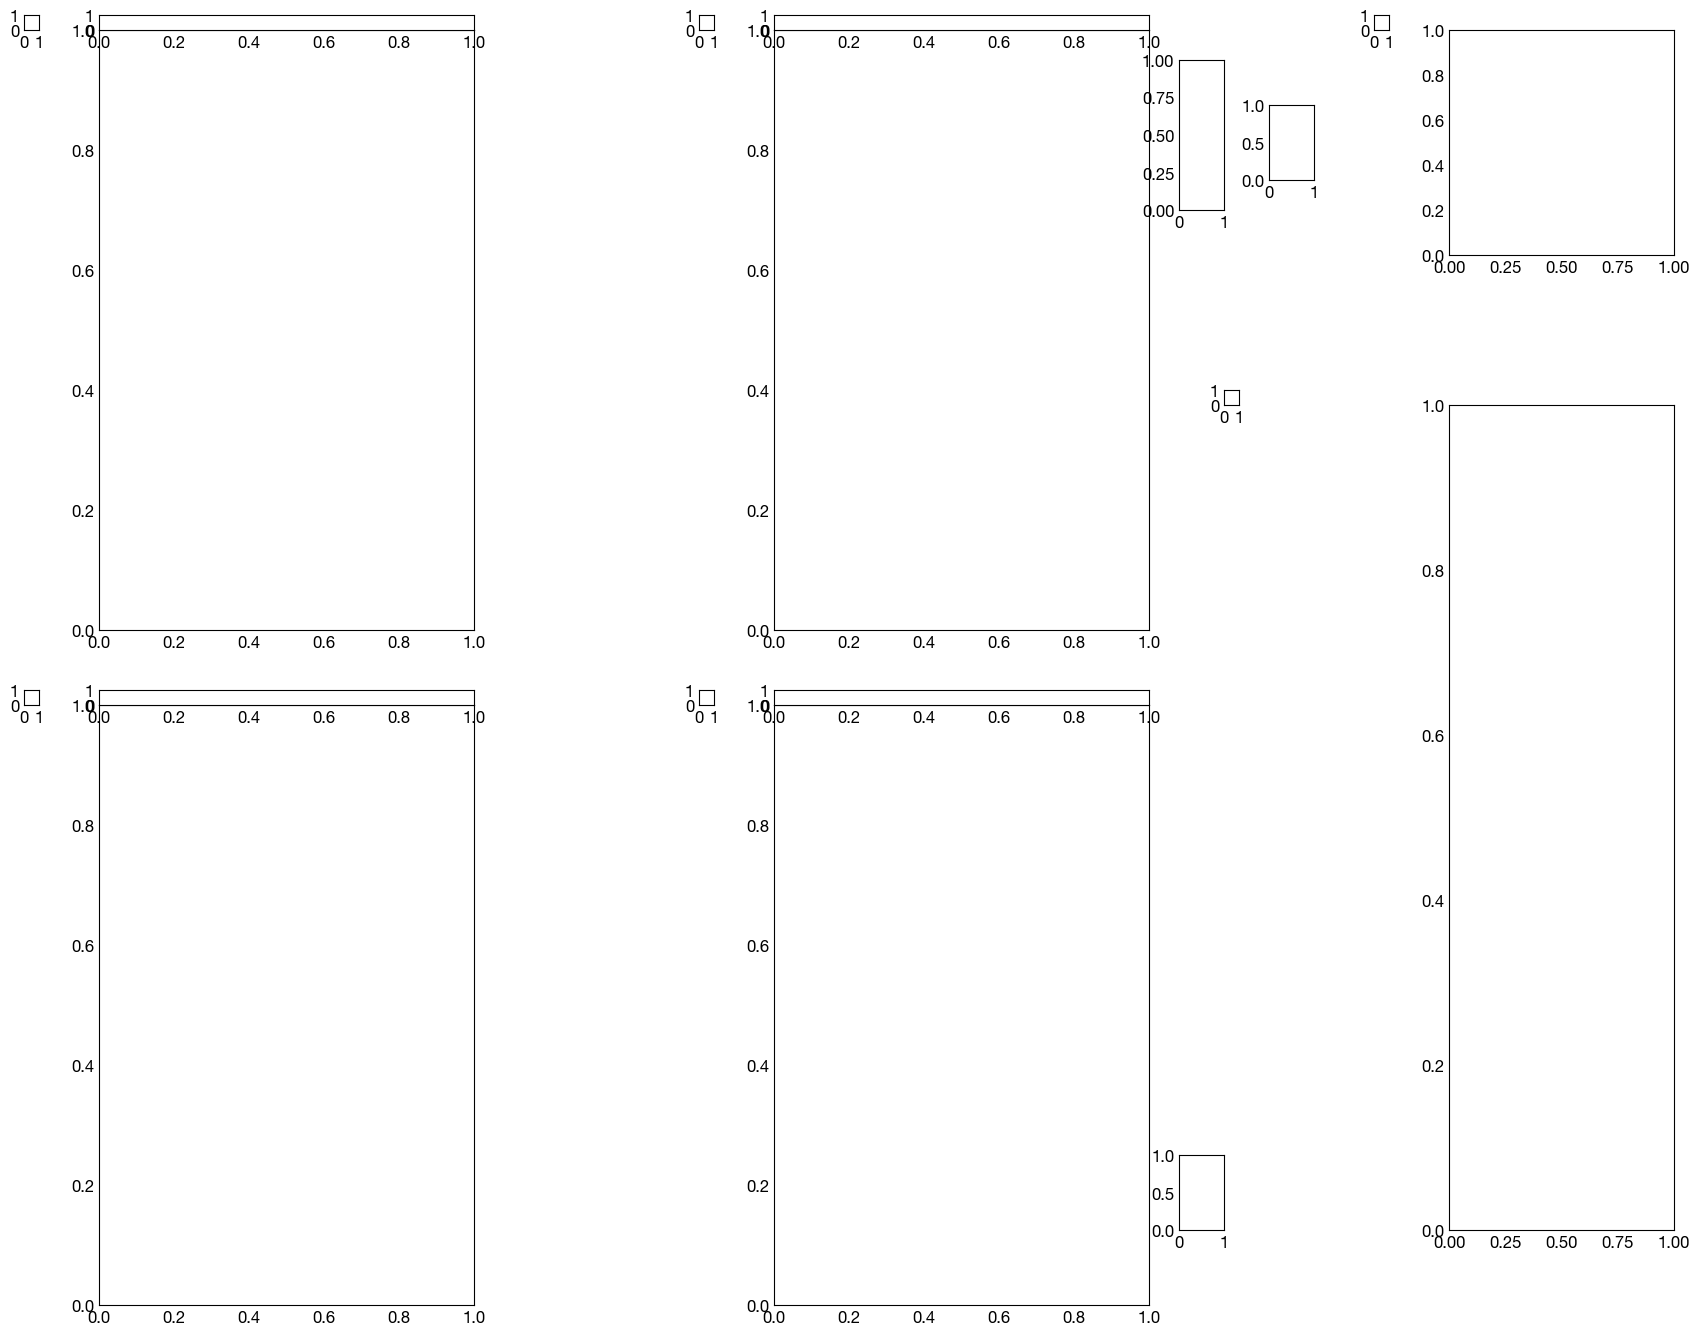

In [3]:
# figure size
WIDTH = 15
HEIGHT = 15

# figure style
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 12
plt.rcParams['xtick.major.size'] = 0
plt.rcParams['ytick.major.size'] = 0
plt.rcParams['pdf.fonttype'] = 42 # need this to open/edit in illustrator - if needed

fig = plt.figure(figsize=(WIDTH, HEIGHT))


### add the axes

# dot plot 1: c1_v1
ax1 = fig.add_axes([0.05, 0.45, 0.25, 0.4])
ax1_cst = fig.add_axes([0.05, 0.85, 0.25, 0.01])
ax1.sharex(ax1_cst)

# dot plot 2: c2_v2
ax2 = fig.add_axes([0.5, 0.45, 0.25, 0.4])
ax2_cst = fig.add_axes([0.5, 0.85, 0.25, 0.01])
ax2.sharex(ax2_cst)

# dot plot 3: c1_c2
ax3 = fig.add_axes([0.05, 0, 0.25, 0.4])
ax3_cst = fig.add_axes([0.05, 0.4, 0.25, 0.01])
ax3.sharex(ax3_cst)

# dot plot 4: v1_v2
ax4 = fig.add_axes([0.5, 0, 0.25, 0.4])
ax4_cst = fig.add_axes([0.5, 0.4, 0.25, 0.01])
ax4.sharex(ax4_cst)

# concordance proportions
ax5 = fig.add_axes([0.95, 0.7, 0.15, 0.15])

# monophyletic proportions proportions
ax6 = fig.add_axes([0.95, 0.05, 0.15, 0.55])

# cst color bar
cbar_ax_cst = fig.add_axes([0.77, 0.73, 0.03, 0.1])

# concordance color legend
cbar_ax_concord = fig.add_axes([0.83, 0.75, 0.03, 0.05])

# monophyletic analysis legend
mp_legend_ax = fig.add_axes([0.77, 0.05, 0.03, 0.05])

# axes for the figure labels
a_ax = fig.add_axes([0, 0.85, 0.01, 0.01])
b_ax = fig.add_axes([0.45, 0.85, 0.01, 0.01])
c_ax = fig.add_axes([0, 0.40, 0.01, 0.01])
d_ax = fig.add_axes([0.45, 0.40, 0.01, 0.01])
e_ax = fig.add_axes([0.90, 0.85, 0.01, 0.01])
f_ax = fig.add_axes([0.8, 0.60, 0.01, 0.01])

## Concordance Dot Plots

In [4]:
# instrain results import and processing
from fig2_datasets import instrain_result_processingV2 as ip

Approach to identify if a reference genome is present in a sample: compare the[ breadth vs the expected breadth](https://instrain.readthedocs.io/en/latest/important_concepts.html#detecting-organisms-in-metagenomic-data) of mapping a specific sample to the reference. Instead of imposing the filter at the patient level (i.e. removing patients who dont meet the breadth cutoff in at least one of their samples), the filter will be imposed at the individual comparison level (i.e. at least one of the samples in the comparison needs to meet the breadth cutoff for it to be considered in the analysis.) 

Following the documentation, if the breadth is >=50%, it will be assumed that the reference genome is in the sample. If the breadth is <50%, it will be compared to the expected breadth based off the coverage to determine if the reference genome (i.e. MAG) is in the sample community. 

In [5]:
instrain_results = ip.processed_instrain_results
instrain_results['name1_breadth_passed'] = instrain_results[['genome', 'name1']].apply(lambda r: ip.has_genome_by_breadth(r['name1'], r['genome']), axis=1)
instrain_results['name2_breadth_passed'] = instrain_results[['genome', 'name2']].apply(lambda r: ip.has_genome_by_breadth(r['name2'], r['genome']), axis=1)
instrain_results = instrain_results[(instrain_results['name1_breadth_passed'] == True) & (instrain_results['name2_breadth_passed'] == True)]

#rename the taxa so they are compatible with VIRGO2 mapping results
instrain_results_gtdb_taxa = instrain_results
instrain_results = instrain_results.replace({'taxa':{'^Bifidobacterium_vaginale' : 'Gardnerella_vaginalis', '^UBA629_sp005465875':'BVAB1', 'Bifidobacterium_swidsinskii':'Gardnerella_swidsinskii', 'Bifidobacterium_leopoldii':'Gardnerella_leopoldii', 'Bifidobacterium_piotii':'Gardnerella_piotii', 'KA00274_sp902373515':'BVAB2', 'Bifidobacterium':'Gardnerella'}}, regex=True)

In [6]:
#setting cutoff for concordance
percent_comp_cutoff = 0.50
popANI_cutoff = 0.999999

below_lod_data = instrain_results[(instrain_results['name1_breadth_passed'] == False) | (instrain_results['name2_breadth_passed'] == False) | (instrain_results['percent_compared'] < percent_comp_cutoff)]
below_lod_data['comp_cat'] = 'LOD'

concord_data = instrain_results[(instrain_results['name1_breadth_passed'] == True) & (instrain_results['name2_breadth_passed'] == True) & (instrain_results['percent_compared'] >= percent_comp_cutoff) & (instrain_results['popANI'] >= popANI_cutoff)]
concord_data['comp_cat'] = 'C'

discord_data = instrain_results[(instrain_results['name1_breadth_passed'] == True) & (instrain_results['name2_breadth_passed'] == True) & (instrain_results['percent_compared'] >= percent_comp_cutoff) & (instrain_results['popANI'] < popANI_cutoff)]
discord_data['comp_cat'] = 'D'

parsed_data = pd.concat([below_lod_data, concord_data, discord_data], axis=0)
parsed_data['-log10_popANI'] = -1*(np.log10(parsed_data['popANI']))

/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_90008/4014423572.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  below_lod_data['comp_cat'] = 'LOD'
/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_90008/4014423572.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  concord_data['comp_cat'] = 'C'
/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_90008/4014423572.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

In [7]:
target_comparisions = ['c1_v1', 'c2_v2', 'c1_c2', 'v1_v2']
target_comp_data = parsed_data[~(parsed_data['comp_cat'] == 'LOD')]
target_comp_data = target_comp_data[target_comp_data['compare_type'].isin(target_comparisions)]

target_comp_data = (
    target_comp_data.sort_values(by='percent_compared', ascending=False)
    .groupby(['compare_type', 'taxa', 'pt_id'], as_index=False)
    .first()
)


In [8]:
#merge the cst info
cst_assignments = pd.read_csv('./common/mmtm_cst_assignments_taxa_corr.csv')
target_comp_data['name1_cst'] = target_comp_data['name1'].apply(lambda x: cst_assignments[cst_assignments['sampleID'] == x]['CST'].values[0])
target_comp_data['name2_cst'] = target_comp_data['name2'].apply(lambda x: cst_assignments[cst_assignments['sampleID'] == x]['CST'].values[0])

In [9]:
def format_title(target, split=' vs. '):
    ''' 
    Returns a formatted title for the plot based of the comparision.
    '''

    title = []
    samps = target.split('_')

    for s in samps:
        temp = ''
        if s[0] == 'c':
            temp += 'Cervix'
        else:
            temp += 'Vagina'
        
        if s[1] == '1':
            temp += '-Timepoint 1'
        else:
            temp += '-Timepoint 2'
        title.append(temp)
    
    title = split.join(title)

    return title

/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_90008/2516079136.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curr_target_comp_data['comp_cat2'] = pd.cut(curr_target_comp_data['popANI'], bins=[0, 0.9999, 0.999999, 1], labels=['LOW', 'MEDIUM', 'HIGH'], right=True)
/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_90008/2516079136.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curr_target_comp_data['comp_cat2'] = curr_target_comp_data['comp_cat2'].astype(str)
/var/folders/vp/

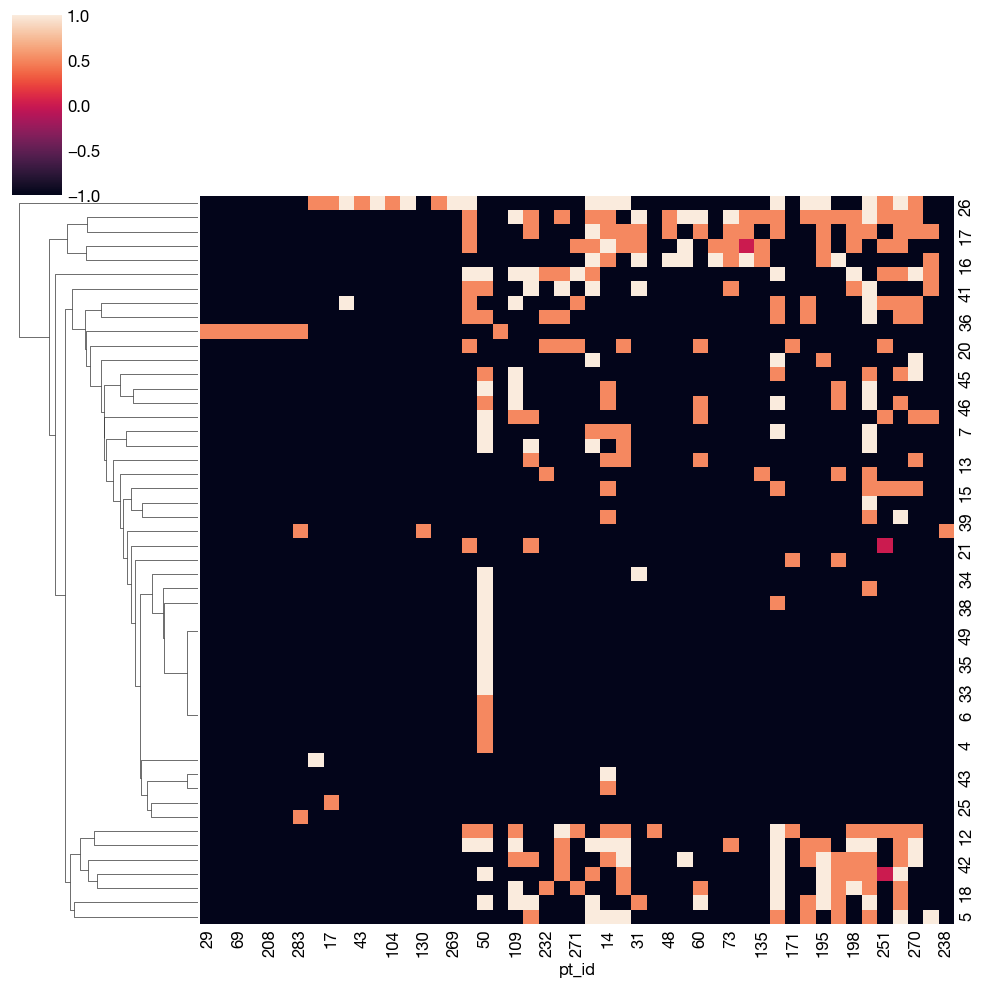

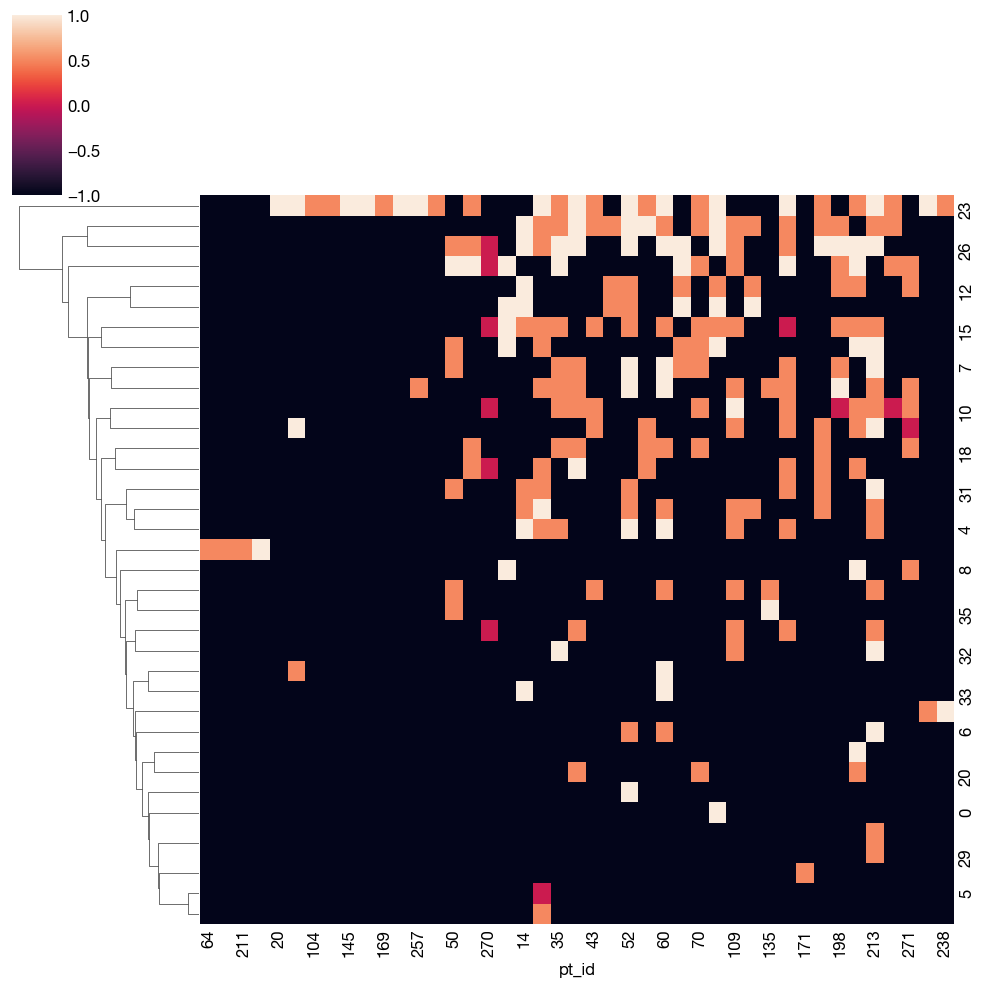

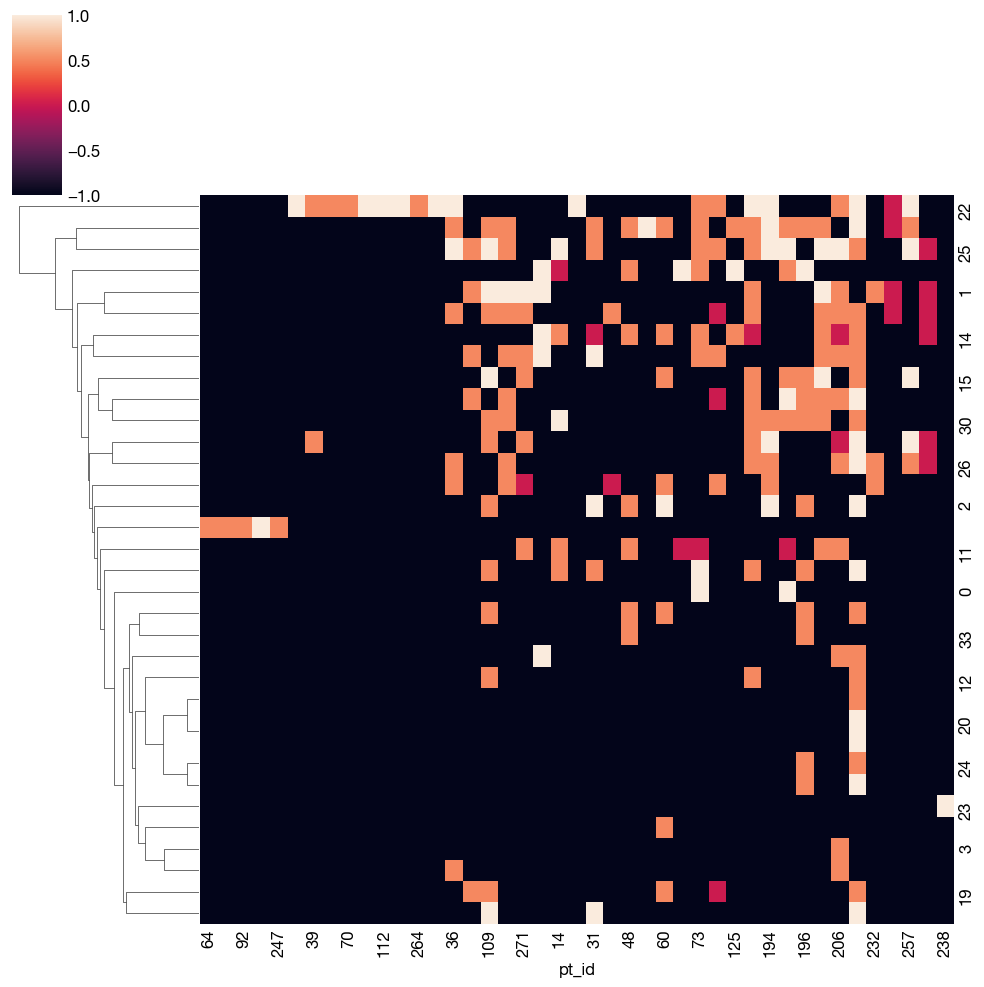

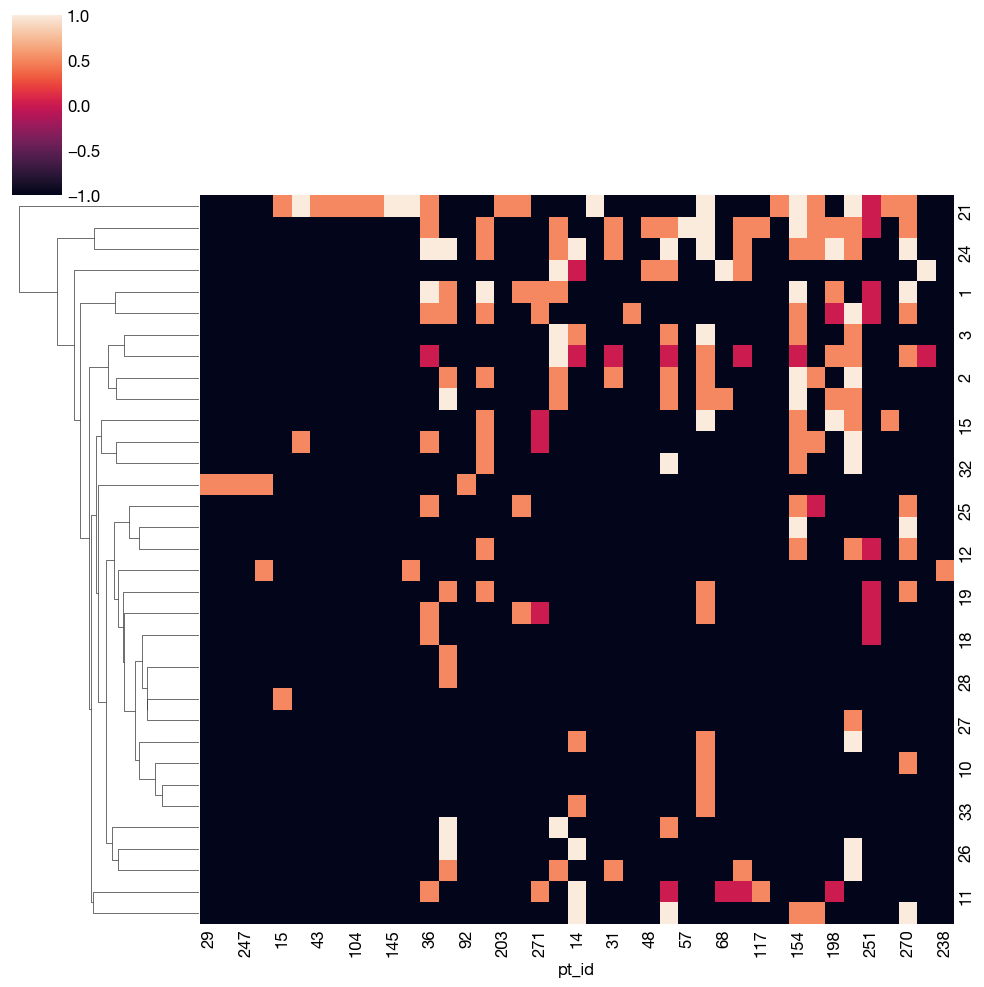

In [10]:
dot_plot_axes = [
    (ax1, ax1_cst),
    (ax2, ax2_cst),
    (ax3, ax3_cst),
    (ax4, ax4_cst),
]

for target in target_comparisions:

    #set the axes for this plot
    curr_axes = dot_plot_axes.pop(0)
    dot_ax = curr_axes[0]
    cst_ax = curr_axes[1]

    curr_target_comp_data = target_comp_data[target_comp_data['compare_type'] == target]
    curr_target_comp_data['comp_cat2'] = pd.cut(curr_target_comp_data['popANI'], bins=[0, 0.9999, 0.999999, 1], labels=['LOW', 'MEDIUM', 'HIGH'], right=True)
    curr_target_comp_data['comp_cat2'] = curr_target_comp_data['comp_cat2'].astype(str)

    #get the patient order with the sample csts
    ordered_patients_cst = curr_target_comp_data[['pt_id', 'name1_cst', 'name2_cst']].groupby('pt_id').first().sort_values(by=['name1_cst', 'pt_id']).reset_index()

    ##plot the cst comps
    ax = cst_ax
    x_pos = 0
    for index, row in ordered_patients_cst.iterrows():

        #plot the name1 cst
        ax.bar(x=x_pos, height=0.25, bottom=0.3, color=cst_colors[row['name1_cst']], width=1)
        #ax.plot([x_pos], [1], marker=(3, 0, -45), markersize=10, color=cst_cmap[row['name1_cst']])

        #plot the name2 cst
        ax.bar(x=x_pos, height=0.25, bottom=0, color=cst_colors[row['name2_cst']], width=1)
        #ax.plot([x_pos], [0], marker=(3, 0, 45), markersize=10, color=cst_cmap[row['name2_cst']])

        x_pos += 1

    ax.set_ylim((0,2))
    ax.spines[['right', 'left', 'bottom', 'top']].set_visible(False)
    ax.set_title(format_title(target), fontsize=15)
    ax.set_yticks([0.15, 0.55])
    ax.set_yticklabels(['CST_2', 'CST_1'], fontsize=6)
    ax.set_ylim(0,0.6)
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.set_xticklabels([])

    curr_target_comp_data = curr_target_comp_data[['taxa', 'pt_id', 'comp_cat2']]
    curr_target_comp_data = curr_target_comp_data.pivot(columns='pt_id', values='comp_cat2', index='taxa').reset_index()
    

    curr_target_comp_data = curr_target_comp_data.replace({'HIGH':1, 'MEDIUM':0.5 ,'LOW':0})
    cols = ['taxa']
    for p in list(ordered_patients_cst['pt_id'].values):
        cols.append(p)
    curr_target_comp_data = curr_target_comp_data[cols]
    
    plot_data = sns.clustermap(curr_target_comp_data.iloc[:,1:].fillna(-1), col_cluster=False).data2d
    plot_data['taxa'] = [curr_target_comp_data.iloc[i, 0:1].values[0] for i in plot_data.index]


    ##plot the binary plot
    ax = dot_ax

    y_ticks = []
    temp = plot_data.replace({-1:np.nan}).dropna(thresh=3)
    y_pos = len(temp)
    for index, row in temp.iterrows():
        x_pos = 0
        y_ticks.append(y_pos)
        for v in row.fillna(-1).values[:-1]:
            if v != -1:
                ax.plot([x_pos], [y_pos], marker='.', markersize=6, color=concord_colors[v])
            x_pos += 1
    
        y_pos -= 1

    taxa_rename = {'BVAB1':'Ca. L. vaginae', 'BVAB2':'Amygdalobacter_indicium'}
    rename = lambda x: taxa_rename[x] if x in taxa_rename else x

    ax.set_yticks(y_ticks)
    ax.set_yticklabels([rename(t).replace('_', ' ') for t in list(temp['taxa'].values)], fontstyle='italic', fontfamily='Arial')

    ax.set_xticklabels([])
    

## Concordance Proportions

In [11]:
# set up data to calculate proportions of difference concordance events per comparision type
concord_prop_data = target_comp_data
concord_prop_data['comp_cat2'] = pd.cut(concord_prop_data['popANI'], bins=[0, 0.9999, 0.999999, 1], labels=['LOW', 'MEDIUM', 'HIGH'], right=True)
concord_prop_data['comp_cat2'] = concord_prop_data['comp_cat2'].astype(str)
concord_prop_data['comp_cat2'] = concord_prop_data['comp_cat2'].replace({'HIGH':1, 'MEDIUM':0.5 ,'LOW':0})
concord_prop_data = concord_prop_data[['compare_type', 'comp_cat2']]

# keep track of the x position for the bar
loc = 0

# iterate through all of the comparision and make the stacked bar plot
for comp in target_comparisions:
    comp_props = concord_prop_data[concord_prop_data['compare_type'] == comp]
    comp_props = dict(comp_props['comp_cat2'].value_counts(normalize=True))

    bottom = 0

    for c in [0, 0.5, 1]:
        ax5.bar(x=loc, height=comp_props[c], width=0.85, color=concord_colors[c], bottom=bottom)
        bottom += comp_props[c]
    
    loc += 1

# formatting 
ax5.set_xticks([0, 1, 2, 3])
ax5.set_xticklabels([format_title(t, split='\nvs.\n') for t in target_comparisions], rotation=90, fontsize=8)
ax5.set_ylabel('Proportion', fontsize=15)
ax5.set_ylim(0,1)

(0.0, 1.0)

## Monophyletic Proportions

In [12]:
# read in the metadata that will be used to annotate the mags w the bodysite, timepoint, patient id
mmtm_metadata = pd.read_csv('./common/mmtm_metadata.csv')

# read in the list of mags from the gtdbtk results
mags_list = pd.read_csv('./fig2_datasets/gtdbtk.bac120.summary.tsv', sep='\t')
mags_list = mags_list[mags_list.user_genome.str.startswith('MTM')][['user_genome']]
mags_list['sample'] = mags_list['user_genome'].apply(lambda x: x.split('.')[0])
mags_list = pd.merge(mags_list, mmtm_metadata, left_on='sample', right_on='IGS LABEL', how='left').drop('IGS LABEL', axis=1)

# taxa to rename
renaming = {'Bifidobacterium':'Gardnerella', 'KA00274_sp902373515':'BVAB2', 'UBA629_sp005465875':'BVAB1', 'vaginale':'vaginalis'}

In [13]:
# hold the data to be plotted
to_plot = {'taxa':[], 'n':[], 'all_samples':[], 'bodysite':[], 'timepoint':[], 'none':[]}

for file in os.listdir('./fig2_datasets/renamed_trees/'):
    if file[0] == '.':
        continue
    taxa = file.replace('_tree_renamed', '')

    tree = Phylo.read(f'./fig2_datasets/renamed_trees/{taxa}_tree_renamed', 'newick')
    tree.ladderize()

    for old, new in renaming.items():
        taxa = taxa.replace(old, new)

    if taxa not in taxa_color_scheme.keys():
       get_color(taxa)
       taxa_text_legend[taxa] = taxa.replace('_', ' ')


    mags = {n.name:n for n in tree.get_terminals()}
    taxa_mags_info = mags_list[mags_list.user_genome.isin(mags.keys())]

    n = 0 #total number of patients who have more than 1 mag, used for the denominator
    all_samples = 0 #total number of patients with monophyletic samples, considering ALL samples
    bodysite = 0 #total number of patients with monophyletic samples between C and V, at either timepoint
    timepoint = 0 #total number of patients with monophyletic samples between T1 and T2, at either bodysite
    none = 0 #total number of patients with none (or some other monophyletic pattern)

    for pt, data in taxa_mags_info.groupby('Ext Participant ID'):

        #ignore if the patient only has 1 sample
        if len(data) < 2:
            continue

        n += 1        
        pt_mag_clades = [mags[c] for c in data['user_genome'].values]

        if tree.is_monophyletic(pt_mag_clades): #checks all samples
            all_samples += 1
            continue
        
        #checking for bodysite and timepoint specific monophyletics
        is_bodysite = False
        is_timepoint = False

        # checking between bodysites at either timepoint
        for tp in [1, 2]:
            temp_data = data[data['Timepoint'] == tp]

            if len(temp_data) < 2:
                continue

            pt_mag_clades = [mags[c] for c in temp_data['user_genome'].values]
            if tree.is_monophyletic(pt_mag_clades):
                is_bodysite = True
        
        # checking at a given bodysite over time
        for bs in ['C', 'V']:
            temp_data = data[data['Cervix/Vagina'] == bs]

            if len(temp_data) < 2:
                continue

            pt_mag_clades = [mags[c] for c in temp_data['user_genome'].values]
            if tree.is_monophyletic(pt_mag_clades):
                is_timepoint = True
        
        
        # they would both be false here, so continue
        if is_bodysite == is_timepoint:
            none += 1
            continue
        
        # at least 1 is true, record which one
        if is_bodysite:
            bodysite += 1
        
        if is_timepoint:
            timepoint += 1


    if n == 0:
        continue

    to_plot['taxa'].append(taxa)
    to_plot['n'].append(n)
    to_plot['all_samples'].append((all_samples/n))
    to_plot['bodysite'].append((bodysite/n))
    to_plot['timepoint'].append((timepoint/n))
    to_plot['none'].append((none/n))

to_plot = pd.DataFrame(to_plot)


taxa_rename = {'BVAB1':'Ca. L. vaginae', 'BVAB2':'Amygdalobacter indicium'}
rename = lambda x: taxa_rename[x] if x in taxa_rename else x


to_plot = to_plot[to_plot.n >= 5]
to_plot = to_plot.sort_values(by='all_samples')
to_plot['label'] = to_plot['taxa'].str.replace('_', ' ')
to_plot['label'] = to_plot['label'].apply(lambda x: "$\it{%s}$" % (rename(x).replace(" ", "\ ")))
to_plot['label'] = to_plot['label'] + '\n(n=' + to_plot['n'].astype(str) + ')'


alphas = {'all_samples':1, 'bodysite':1, 'timepoint':1, 'none':0.2}
hatchs = {'all_samples':None, 'bodysite':'||||||', 'timepoint':'-------', 'none':None}

loc = 0
for index, row in to_plot.iterrows():
    bot = 0
    for d in ['all_samples', 'bodysite', 'timepoint', 'none']:
        taxa = row['taxa']
        prop = row[d]
        ax6.barh(y=loc, width=prop, color=taxa_color_scheme[taxa], left=bot, alpha=alphas[d], hatch=hatchs[d], edgecolor='white', linewidth=0)
        bot += prop
    loc += 1

ax6.set_ylim(-1, len(to_plot)+0.1)
ax6.set_yticks(range(len(to_plot)))
ax6.set_yticklabels(to_plot['label'], fontsize=11)
ax6.set_ylabel('Taxa\n(n= # of participants ≥ 2 MAGs)', fontsize=15)
ax6.set_xlabel('Proportion of\nMonophyletic Patients', fontsize=15)
ax6.set_title('Monophyletic Proportion Analysis\t', fontsize=15)


Text(0.5, 1.0, 'Monophyletic Proportion Analysis\t')

## Add Legends

In [14]:
# add the legends
pt_cbarCST = matplotlib.colorbar.ColorbarBase(cbar_ax_cst, cmap=my_cst_cmap, orientation = 'vertical',ticklocation='right',ticks=[0.08,0.24,0.40,0.56,0.75,0.90])
pt_cbarCST.ax.set_yticklabels(['I', 'II', 'III', 'IV-A', 'IV-B', 'V'],fontsize=8)
cbar_ax_cst.set_ylim(1,0)
cbar_ax_cst.text(0.15,-0.025,r"CST",fontsize=12)

pt_cbarConcord = matplotlib.colorbar.ColorbarBase(cbar_ax_concord, cmap=my_concord_cmap, orientation = 'vertical',ticklocation='right',ticks=[0.16, 0.48, 0.8])
pt_cbarConcord.ax.set_yticklabels(['Low', 'Medium', 'High'],fontsize=8)
cbar_ax_concord.set_ylim(0,1)
cbar_ax_concord.text(-0.42, 1.1,r"Concordance",fontsize=12)


legend_patches = []
legend_patches.append(mpatches.Patch(color='black', label='All Samples'))
legend_patches.append(mpatches.Patch(facecolor='none', edgecolor='black', label='Between Bodysites', hatch=hatchs['bodysite']))
legend_patches.append(mpatches.Patch(facecolor='none', edgecolor='black', label='Between Timepoints', hatch=hatchs['timepoint']))
legend_patches.append(mpatches.Patch(color='black', edgecolor='black', label='Other', alpha=alphas['none']))
mp_legend_ax.legend(handles=legend_patches,loc=[0,0],ncol=1, frameon=False, title='MAGs from:', fontsize=8)
mp_legend_ax.set_axis_off()

/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_90008/2052625155.py:17: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  legend_patches.append(mpatches.Patch(color='black', edgecolor='black', label='Other', alpha=alphas['none']))


## Add Figure Labels

In [15]:
labels = ['A', 'B', 'C', 'D', 'E', 'F']
for ax in [a_ax, b_ax, c_ax, d_ax, e_ax, f_ax]:
    ax.text(x=0,y=0,s=labels.pop(0),fontsize=24, weight='bold')
    ax.set_axis_off()

## Save Figure

In [16]:
fig.savefig('fig2_V2.pdf', format='pdf', bbox_inches='tight')

feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
